<a href="https://colab.research.google.com/github/Goncalotramps/F2L-Data-Treatment/blob/main/tratamento_fotoeletrico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

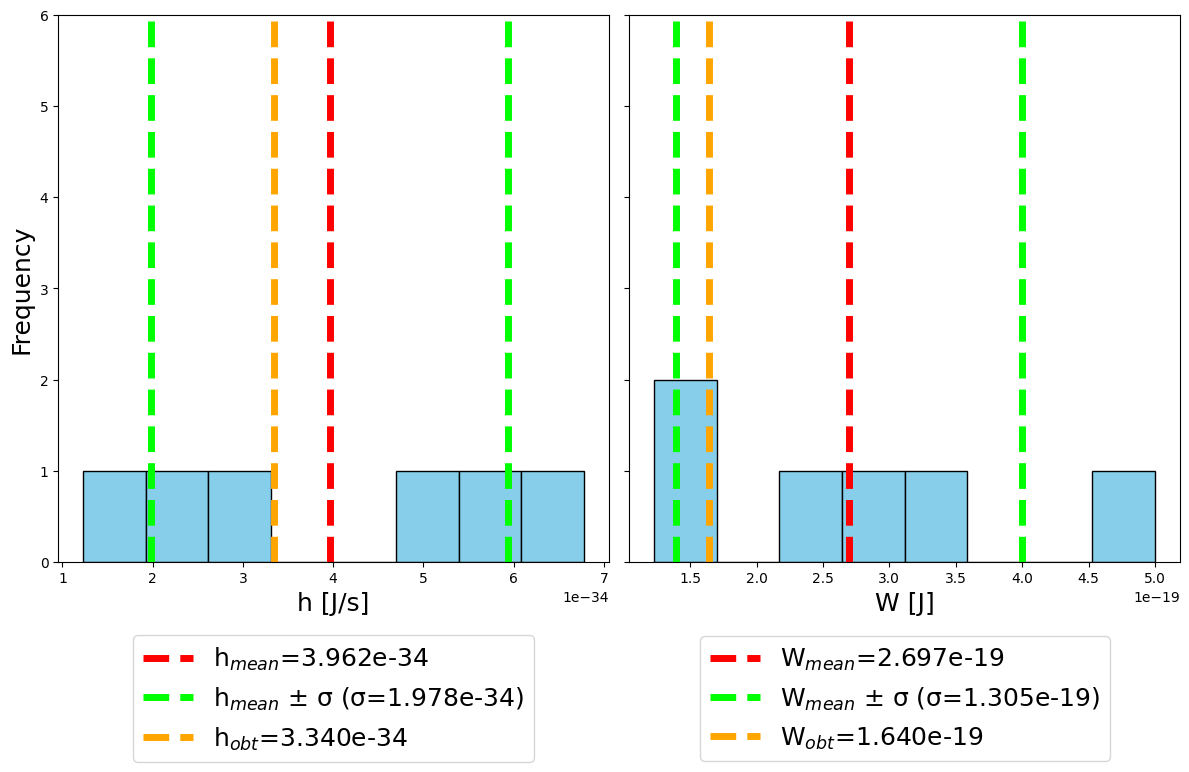

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd

from scipy.stats import norm
import statistics

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 8), sharey=True)

"""""
Precisam apenas de ter atenção a estas 3 coisas:

ver se o ficheiro excel se chama "tratamento_estatistico"

col_name: nome das colunas do ficheiro excel ao qual o codigo vai buscar os valores de h ou W dos vários grupos (são necessárias
2 colunas, uma chamada "h" e a outra "W")

valor_obtido: valores que obtiveram para os vossos dados tanto de h como de W nas unidades corretas


"""""
for col_name,ax,xlabels,valor_obtido in zip(["h","W"],[ax1,ax2],['h [J/s]','W [J]'],[3.34e-34,1.64e-19]):
    # Intitular o ficheiro excel com os valores do calor específico com "tratamento_estatistico" e
    # dar upload ao ficheiro no ícone da pasta do lado esquerdo

    df = pd.read_excel('tratamento_estatistico.xlsx')

    data = df[col_name]

    data= data[np.isfinite(data)]

    # Faz o plot dos histogramas. O número de bins deve ser mudado para o que se achar mais adequado.

    ax.hist(data, bins=8, color='skyblue', edgecolor='black')

    #Cexp corresponde ao valor experimental obtido pelo próprio grupo, e deve ser introduzido aqui pelo mesmo.
    #Atenção: o valor colocado trata-se apenas dum valor ficticio

    #Colocar o número de sigmas (n) para criar um intervalo de confiança no plot
    n=1

    #Calcula o valor médio (mu) e desvio padrão (std) dos dados
    mu, std = norm.fit(data)

    ajuste=20

    #O valor de ajuste serve apenas para melhorar a visualização da distribuição normal no plot.

    #Ajustar o valor do limite superior do eixo vertical para limsup.
    limsup=5

    #Plot duma linha vertical que identifica o valor médio obtido para os dados.

    ax.plot([mu,mu],[0,limsup+1],ls="--",lw=5,c="red",label=f"{col_name}$_{{mean}}$={mu:.3e}")

    #Dependendo se o aluno colocou 1 sigma ou mais sigmas a legenda do plot irá mudar.
    if n==1:
        labelsigma=f"{col_name}$_{{mean}}$ $\pm$ \u03C3 (\u03C3={std:.3e})"
    else:
        labelsigma=f"{col_name}$_{{mean}}$ $\pm$ {n:.0f}\u03C3 (\u03C3={std:.3e})"

    ax.plot([mu-n*std,mu-n*std],[0,limsup+1],ls="--",lw=5,c="lime",label=labelsigma)
    ax.plot([mu+n*std,mu+n*std],[0,limsup+1],ls="--",lw=5,c="lime")
    ax.plot([valor_obtido,valor_obtido],[0,limsup+1],ls="--",lw=5,c="orange",label=f"{col_name}$_{{obt}}$={valor_obtido:.3e}")

    ax.legend(bbox_to_anchor=(0.5, - 0.25), loc="center",fontsize=18)

    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    # Colocar as unidades certas e os nomes das legendas mais convenientes
    ax.set_xlabel(xlabels,fontsize=18)

    ax.set_ylim(0,limsup+1)

    if ax==ax1:
        ax.set_ylabel('Frequency',fontsize=18)


    # Dá o plot final

plt.tight_layout()
plt.savefig("tratamento_dados.png")